# Counterfactual Explanations Tutorial - Artelt & Hammer Method

Welcome to this tutorial on **Artelt & Hammer (2020)** approach to generating counterfactual explanations with convex density constraints!

## What are Plausible Counterfactual Explanations?

While traditional counterfactual explanations answer: *"What would need to change for a different prediction?"*, **plausible counterfactuals** go one step further by ensuring the generated explanations are realistic and feasible.

The key insight of Artelt & Hammer is that counterfactuals should not only change the prediction but also lie within **high-density regions** of the data distribution, making them more plausible and actionable.


# Import necessary libraries

We'll need additional libraries for density estimation and optimization compared to the Wachter method.


In [20]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.optimize import minimize
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## The Artelt & Hammer (2020) Formulation

The paper ["Convex Density Constraints for Computing Plausible Counterfactual Explanations"](https://arxiv.org/pdf/2002.04862) introduces a novel approach that ensures counterfactuals are both **close to the original instance** and **plausible** by lying in high-density regions.

### Key Innovation

Traditional methods like Wachter et al. only consider:
- **Proximity**: Minimize distance to original instance
- **Prediction change**: Achieve desired target prediction

Artelt & Hammer add a third crucial component:
- **Plausibility**: Ensure counterfactual lies in high-density regions of the data distribution

### The Optimization Problem

The authors formulate this as a constrained optimization problem:

**minimize** ||x' - x||₂²  
**subject to** f(x') = y'  
**and** p(x') ≥ τ

Where:
- **x'**: Counterfactual instance
- **x**: Original instance  
- **f(x')**: Model prediction
- **y'**: Target prediction
- **p(x')**: Data density at x'
- **τ**: Density threshold (minimum plausibility level)


## Reformulation as Unconstrained Optimization

To solve this optimization problem using gradient-based methods, we reformulate the constrained problem as an **unconstrained optimization** problem:

### The Loss Function

$$L(x') = \lambda_1 \cdot d(x, x') + \lambda_2 \cdot \ell(f(x'), y') + \lambda_3 \cdot \phi(p(x'))$$

Where:
- **d(x, x')**: Distance function (typically L2 distance: ||x' - x||₂²)
- **ℓ(f(x'), y')**: Loss function measuring how far f(x') is from the target y'
- **φ(p(x'))**: Density penalty function (encourages high-density regions)
- **λ₁, λ₂, λ₃**: Hyperparameters balancing proximity, prediction change, and plausibility

### Distance Component

Same as Wachter method - encourages proximity:

$$d(x, x') = ||x' - x||_2^2 = \sum_{i=1}^{d} (x'_i - x_i)^2$$

### Prediction Loss Component

Same as Wachter method - encourages correct prediction:

$$\ell(f(x'), y') = \max(0, \tau - (f(x') - 0.5) \cdot (2y' - 1))$$

### Density Penalty Component (NEW!)

The key innovation - encourages plausibility:

$$\phi(p(x')) = -\log(p(x'))$$

This penalty is:
- **Low** when p(x') is high (plausible regions)
- **High** when p(x') is low (implausible regions)

### Density Estimation

To compute p(x'), we need to estimate the data density. Common approaches:

1. **Gaussian Mixture Model (GMM)**: Models data as mixture of Gaussians
2. **Kernel Density Estimation (KDE)**: Non-parametric density estimation
3. **Normalizing Flows**: Deep learning-based density estimation

For this tutorial, we'll use **GMM** as it's efficient and works well for the moons dataset.

### Gradient-Based Optimization

The optimization becomes:

$$x'^{(t+1)} = x'^{(t)} - \alpha \nabla_{x'} L(x'^{(t)})$$

Where the gradient includes the density term:

$$\nabla_{x'} L(x') = \lambda_1 \nabla_{x'} d(x, x') + \lambda_2 \nabla_{x'} \ell(f(x'), y') + \lambda_3 \nabla_{x'} \phi(p(x'))$$

The density gradient requires computing:

$$\nabla_{x'} \phi(p(x')) = -\frac{\nabla_{x'} p(x')}{p(x')}$$

This can be computed using automatic differentiation if p(x') is differentiable (e.g., GMM).


## Dataset: Two Moons

We'll use the same "two moons" dataset for consistency with the Wachter tutorial. This dataset is perfect for demonstrating density constraints because:

1. **Clear density patterns**: Each moon forms a high-density region
2. **Low-density gaps**: Space between moons has low density
3. **Visual interpretability**: Easy to see when counterfactuals are plausible vs. implausible


In [21]:
# Generate the two moons dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

print(f"Training set shape: {X_train_tensor.shape}")
print(f"Test set shape: {X_test_tensor.shape}")
print(f"Class distribution - Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}")


Training set shape: torch.Size([800, 2])
Test set shape: torch.Size([200, 2])
Class distribution - Class 0: 400, Class 1: 400


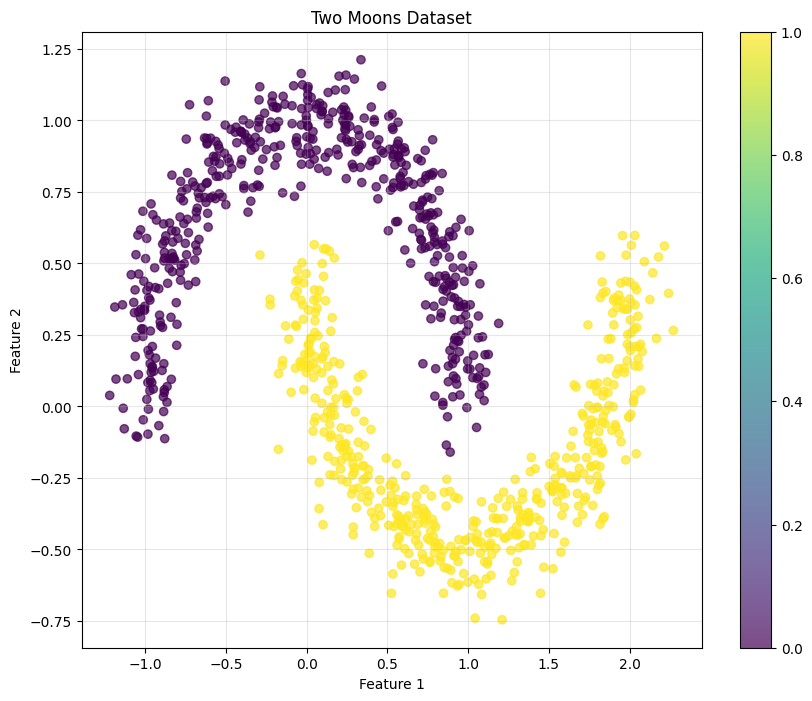

In [22]:
# Visualize the dataset
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title('Two Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()


## Neural Network Model

We'll use the same neural network architecture as in the Wachter tutorial for consistency.


In [23]:
class MoonClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=2):
        super(MoonClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)
    
    def predict_proba(self, x):
        """Return probability predictions"""
        with torch.no_grad():
            logits = self.forward(x)
            return torch.softmax(logits, dim=1)

# Create and initialize model
model = MoonClassifier().to(device)

print("Model architecture:")
print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")


Model architecture:
MoonClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Number of parameters: 4482


## Model Training


In [24]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training loop
num_epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += batch_y.size(0)
        correct_predictions += (predicted == batch_y).sum().item()
    
    # Calculate average loss and accuracy for the epoch
    avg_loss = epoch_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

print("Training completed!")


Epoch [20/100], Loss: 0.0002, Accuracy: 1.0000
Epoch [40/100], Loss: 0.0001, Accuracy: 1.0000
Epoch [60/100], Loss: 0.0000, Accuracy: 1.0000
Epoch [80/100], Loss: 0.0000, Accuracy: 1.0000
Epoch [100/100], Loss: 0.0000, Accuracy: 1.0000
Training completed!


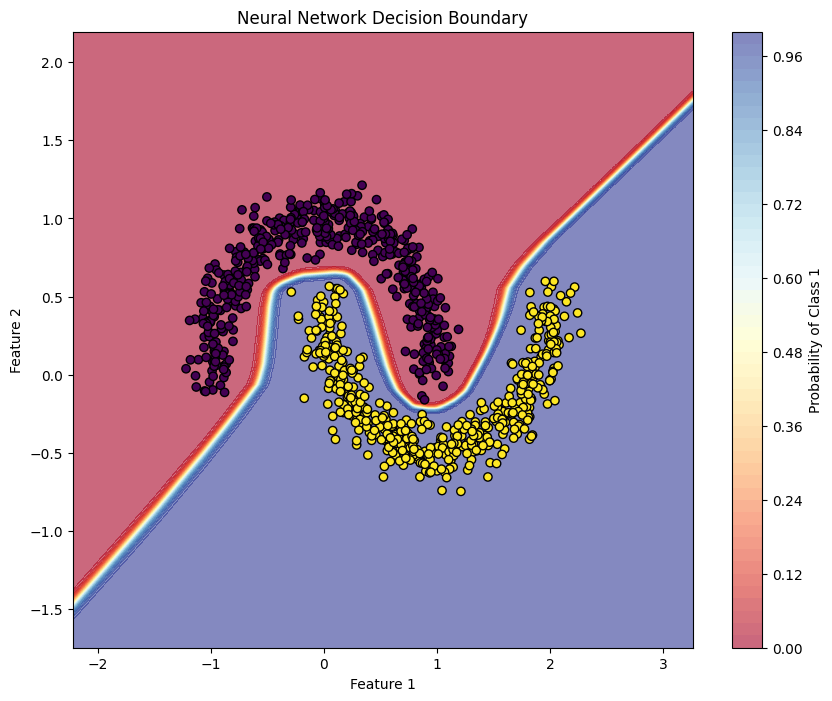

In [26]:
# Visualize decision boundary
def plot_decision_boundary(model, X, y, scaler, title="Decision Boundary"):
    """Plot the decision boundary of the trained model"""
    model.eval()
    
    # Create a mesh
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Make predictions on the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_points_scaled = scaler.transform(mesh_points)
    mesh_tensor = torch.FloatTensor(mesh_points_scaled).to(device)
    
    with torch.no_grad():
        mesh_predictions = model.predict_proba(mesh_tensor)[:, 1].cpu().numpy()
    
    mesh_predictions = mesh_predictions.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, mesh_predictions, levels=50, alpha=0.6, cmap='RdYlBu')
    plt.colorbar(label='Probability of Class 1')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot the decision boundary
plot_decision_boundary(model, X, y, scaler, "Neural Network Decision Boundary")


## Density Estimation

Now we need to estimate the data density to implement the plausibility constraint. We'll use a Gaussian Mixture Model (GMM) to model the data distribution.


GMM fitted with 10 components
Converged: True
Log-likelihood: -1.7866


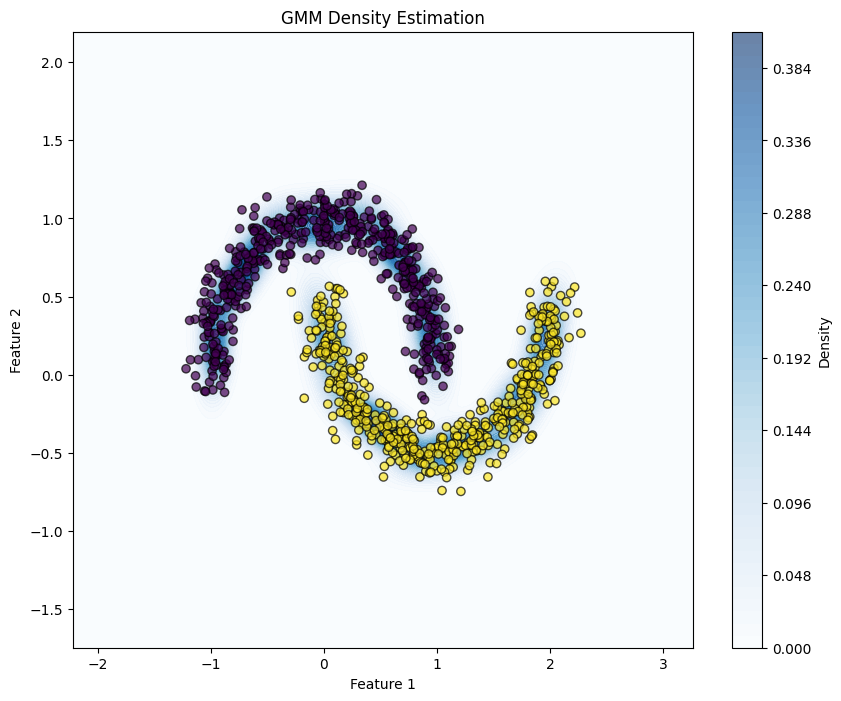

In [27]:
# Fit Gaussian Mixture Model for density estimation
gmm = GaussianMixture(n_components=10, random_state=42)
gmm.fit(X_train_scaled)

print(f"GMM fitted with {gmm.n_components} components")
print(f"Converged: {gmm.converged_}")
print(f"Log-likelihood: {gmm.score(X_train_scaled):.4f}")

# Visualize the density
def plot_density_estimation(gmm, X, y, scaler, title="Data Density Estimation"):
    """Plot the density estimation"""
    # Create a mesh
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Compute density on the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_points_scaled = scaler.transform(mesh_points)
    
    # Get density scores
    density_scores = np.exp(gmm.score_samples(mesh_points_scaled))
    density_scores = density_scores.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, density_scores, levels=50, alpha=0.6, cmap='Blues')
    plt.colorbar(label='Density')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black', alpha=0.7)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot the density estimation
plot_density_estimation(gmm, X, y, scaler, "GMM Density Estimation")


---

# 🚀 **YOUR TURN: Implement Plausible Counterfactual Generation**

Now it's time for you to implement the Artelt & Hammer counterfactual generation algorithm!

## Task Overview

Your goal is to implement a `PlausibleCounterfactualGenerator` class that:

1. **Takes an input instance** and finds the closest plausible counterfactual explanation
2. **Uses gradient-based optimization** to minimize the loss function: `L(x') = λ₁ * d(x, x') + λ₂ * ℓ(f(x'), y') + λ₃ * φ(p(x'))`
3. **Ensures plausibility** by incorporating density constraints
4. **Returns the counterfactual instance** that changes the model's prediction while staying in high-density regions

## Implementation Guidelines

### Class Structure
```python
class PlausibleCounterfactualGenerator:
    def __init__(self, model, gmm, lambda1=1.0, lambda2=1.0, lambda3=1.0, lr=0.01, max_iterations=1000):
        # Initialize your plausible counterfactual generator
        pass
    
    def generate(self, x_orig, target_class, tolerance=0.1):
        # Generate plausible counterfactual explanation for x_orig
        # Returns: counterfactual instance, success flag, iterations used
        pass
```

### Key Components to Implement

1. **Distance Function**: Implement L2 distance `d(x, x')`
2. **Prediction Loss**: Choose between margin loss or cross-entropy loss
3. **Density Penalty**: Implement `φ(p(x')) = -log(p(x'))`
4. **Gradient Optimization**: Use PyTorch's autograd for gradient computation
5. **Stopping Criteria**: Stop when target prediction is achieved or max iterations reached

### Hints

- Initialize `x'` as a copy of the original input `x`
- Make `x'` a PyTorch tensor with `requires_grad=True`
- Use `torch.optim.Adam` or `torch.optim.SGD` for optimization
- For density computation, you'll need to convert PyTorch tensors to numpy for GMM
- Consider using `torch.autograd.Function` for custom density gradient computation
- Track all three loss components separately for debugging

### Density Gradient Computation

The tricky part is computing gradients through the GMM density function. You have several options:

1. **Finite differences**: Approximate gradients numerically
2. **Custom autograd function**: Implement the GMM gradient manually
3. **PyTorch GMM**: Use a PyTorch implementation of GMM (if available)

For simplicity, you can start with finite differences and then optimize if needed.

## Your Implementation Space

👇 **Write your code in the cells below** 👇


In [28]:
# TODO: Implement your PlausibleCounterfactualGenerator class here

class PlausibleCounterfactualGenerator:
    def __init__(self, model, gmm, lambda1=1.0, lambda2=1.0, lambda3=1.0, lr=0.01, max_iterations=1000):
        """
        Initialize the plausible counterfactual generator
        
        Args:
            model: Trained PyTorch model
            gmm: Fitted Gaussian Mixture Model for density estimation
            lambda1: Weight for distance loss
            lambda2: Weight for prediction loss  
            lambda3: Weight for density penalty
            lr: Learning rate for optimization
            max_iterations: Maximum number of optimization steps
        """
        # YOUR CODE HERE
        pass
    
    def distance_loss(self, x_orig, x_cf):
        """
        Compute L2 distance between original and counterfactual
        
        Args:
            x_orig: Original input
            x_cf: Counterfactual input
            
        Returns:
            L2 distance loss
        """
        # YOUR CODE HERE
        pass
    
    def prediction_loss(self, x_cf, target_class):
        """
        Compute prediction loss (how far is the prediction from target)
        
        Args:
            x_cf: Counterfactual input
            target_class: Desired target class
            
        Returns:
            Prediction loss
        """
        # YOUR CODE HERE
        pass
    
    def density_penalty(self, x_cf):
        """
        Compute density penalty (encourages high-density regions)
        
        Args:
            x_cf: Counterfactual input
            
        Returns:
            Density penalty (negative log density)
        """
        # YOUR CODE HERE
        # Hint: Convert x_cf to numpy, compute density with GMM, convert back to tensor
        pass
    
    def generate(self, x_orig, target_class, tolerance=0.1):
        """
        Generate plausible counterfactual explanation
        
        Args:
            x_orig: Original input instance
            target_class: Desired target class (0 or 1)
            tolerance: Tolerance for stopping criterion
            
        Returns:
            counterfactual: Generated counterfactual instance
            success: Whether counterfactual was successfully found
            iterations: Number of optimization iterations used
            loss_history: History of loss components
        """
        # YOUR CODE HERE
        pass

# TODO: Test your implementation with some examples from the test set


In [29]:
# TODO: Test your implementation
# Example usage:
# generator = PlausibleCounterfactualGenerator(model, gmm, lambda1=1.0, lambda2=1.0, lambda3=0.5)
# 
# # Test on a few examples
# for i in range(3):
#     x_test = X_test_tensor[i:i+1]
#     original_pred = model.predict_proba(x_test)[0, 1].item()
#     target_class = 1 if original_pred < 0.5 else 0
#     
#     cf, success, iterations, loss_history = generator.generate(x_test, target_class)
#     
#     print(f"Example {i+1}:")
#     print(f"  Original prediction: {original_pred:.3f}")
#     print(f"  Target class: {target_class}")
#     print(f"  Success: {success}")
#     print(f"  Iterations: {iterations}")
#     print(f"  Counterfactual: {cf.detach().cpu().numpy()}")
#     print()


---

# 📊 **Visualization Space**

Once you've implemented the counterfactual generator, use this space to create visualizations that compare:

1. **Original vs Counterfactual**: Show the original instance and its counterfactual
2. **Density Comparison**: Show where counterfactuals lie in the density landscape
3. **Loss Components**: Plot the evolution of distance, prediction, and density losses
4. **Comparison with Wachter**: Compare plausible vs. non-plausible counterfactuals

👇 **Add your visualizations here** 👇


In [30]:
# TODO: Add visualizations here
# Example visualization functions you might want to implement:

# def plot_counterfactual_comparison(x_orig, x_cf, model, gmm, scaler):
#     """Plot original vs counterfactual with decision boundary and density"""
#     pass
# 
# def plot_loss_evolution(loss_history):
#     """Plot the evolution of loss components during optimization"""
#     pass
# 
# def plot_density_landscape_with_counterfactuals(x_orig, x_cf, gmm, scaler):
#     """Plot counterfactuals on the density landscape"""
#     pass


## Summary

In this tutorial, you've learned about the **Artelt & Hammer (2020)** approach to generating plausible counterfactual explanations:

### Key Concepts

1. **Plausibility Constraint**: Counterfactuals should lie in high-density regions of the data distribution
2. **Three-Component Loss**: Distance + Prediction + Density penalty
3. **Density Estimation**: Using GMM to model data distribution
4. **Gradient Optimization**: Minimizing the combined loss function

### Advantages over Wachter Method

- **More realistic**: Counterfactuals are more likely to occur in practice
- **Better interpretability**: Users can trust that changes are feasible
- **Robust**: Less likely to generate out-of-distribution examples

### Challenges

- **Computational complexity**: Requires density estimation and gradient computation
- **Hyperparameter tuning**: Need to balance three loss components
- **Density estimation quality**: Results depend on the quality of density model

### Next Steps

Consider exploring:
- Different density estimation methods (KDE, Normalizing Flows)
- Adaptive hyperparameter selection
- Comparison with other plausibility constraints
- Application to higher-dimensional datasets
